<a href="https://colab.research.google.com/github/Daheeyah/Daheeyah/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost scikit-learn shap matplotlib seaborn \
    pandas numpy Pillow tqdm openpyxl reportlab \
    fastapi uvicorn python-multipart nest-asyncio pyngrok

print("✅ All dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 53.9 MB/s eta 0:00:00
✅ All dependencies installed


In [11]:

import os, io, json, pickle, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve
)
import shap

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

✅ Device: cuda


In [9]:


# ── Unzip & Load ──────────────────────────────────────────────
!unzip -o "/content/PCOS_data_without_infertility.xlsx.zip" -d "/content/"

print("=== Loading Tabular Data ===")
df = pd.read_excel(
    '/content/PCOS_data_without_infertility.xlsx',
    sheet_name='Full_new'
)

# ── Basic Cleaning ────────────────────────────────────────────
df.columns  = df.columns.str.strip()
df          = df.drop(['Sl. No', 'Patient File No.'], axis=1, errors='ignore')
df          = df.fillna(df.median(numeric_only=True))

# Encode any remaining categoricals
for col in df.select_dtypes(include='object').columns:
    if col != 'PCOS (Y/N)':
        df[col] = pd.factorize(df[col])[0]

# ── Encode Target ─────────────────────────────────────────────
# Convert Y/N to 1/0 if needed
if df['PCOS (Y/N)'].dtype == object:
    df['PCOS (Y/N)'] = df['PCOS (Y/N)'].map({'Y': 1, 'N': 0})

# ── Feature Engineering ───────────────────────────────────────
print("=== Engineering Features ===")
df['BMI']            = df['Weight (Kg)'] / ((df['Height(Cm)'] / 100) ** 2)
df['LH_FSH_Ratio']   = df['LH(mIU/mL)'] / (df['FSH(mIU/mL)'] + 1e-5)
df['Follicle_Total'] = df['Follicle No. (L)'] + df['Follicle No. (R)']
df['WHtR']           = df['Waist(inch)'] / (df['Height(Cm)'] * 0.393701)

# ── Outlier Removal ───────────────────────────────────────────
df = df[df['BMI'].between(10, 60)]
df = df[df['AMH(ng/mL)'] < df['AMH(ng/mL)'].quantile(0.99)]
df = df.dropna()

# ── Separate Features & Labels ────────────────────────────────
X_tab = df.drop('PCOS (Y/N)', axis=1)
y_tab = df['PCOS (Y/N)'].values.astype(int)

print(f"✅ Tabular shape    : {X_tab.shape}")
print(f"   PCOS patients   : {y_tab.sum()}")
print(f"   Healthy patients: {(y_tab==0).sum()}")
print(f"\nFeatures:\n{X_tab.columns.tolist()}")

Archive:  /content/PCOS_data_without_infertility.xlsx.zip
  inflating: /content/PCOS_data_without_infertility.xlsx  
  inflating: /content/PCOS_infertility.csv  
=== Loading Tabular Data ===
=== Engineering Features ===
✅ Tabular shape    : (535, 45)
   PCOS patients   : 174
   Healthy patients: 361

Features:
['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)',

In [13]:

# ── Unzip datasets ────────────────────────────────────────────
!unzip -o "/content/PCOS detection using ultrasound images.zip" \
    -d "/content/ultrasound_A/"
!unzip -o "/content/PCOS-XAI Ultrasound Real-World Training Dataset.zip" \
    -d "/content/ultrasound_B/"

# ── Check what folders were created ──────────────────────────
print("Dataset A contents:", os.listdir('/content/ultrasound_A/'))
print("Dataset B contents:", os.listdir('/content/ultrasound_B/'))


# ── Image Dataset Class ───────────────────────────────────────
class PCOSImageDataset(Dataset):
    """
    Loads images from multiple root directories.
    Folder names:
      infected / PCOS   → label 1
      notinfected /
      noninfected /
      Normal            → label 0
    """
    def __init__(self, root_dirs, transform=None):
        self.transform   = transform
        self.image_paths = []
        self.labels      = []

        if isinstance(root_dirs, str):
            root_dirs = [root_dirs]

        pcos_folders    = ['infected', 'PCOS', 'pcos']
        healthy_folders = ['notinfected', 'noninfected',
                           'Normal', 'normal', 'healthy']

        for root_dir in root_dirs:
            for folder, label in (
                [(f, 1) for f in pcos_folders] +
                [(f, 0) for f in healthy_folders]
            ):
                path = os.path.join(root_dir, folder)
                if os.path.exists(path):
                    for fname in os.listdir(path):
                        if fname.lower().endswith(
                            ('.png', '.jpg', '.jpeg')
                        ):
                            self.image_paths.append(
                                os.path.join(path, fname)
                            )
                            self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(
                self.image_paths[idx]
            ).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ── Discover correct image paths ─────────────────────────────
# Walk directories to find where infected/notinfected folders are
def find_image_dirs(base):
    found = []
    for root, dirs, files in os.walk(base):
        for d in dirs:
            if d.lower() in ['infected', 'notinfected',
                              'noninfected', 'normal',
                              'pcos', 'healthy']:
                found.append(root)
                break
    return list(set(found))

dirs_A = find_image_dirs('/content/ultrasound_A/')
dirs_B = find_image_dirs('/content/ultrasound_B/')
all_image_dirs = dirs_A + dirs_B

print(f"\nFound image directories: {all_image_dirs}")

# ── Load raw dataset (no transform yet) ──────────────────────
raw_dataset = PCOSImageDataset(root_dirs=all_image_dirs)
print(f"\nTotal images found   : {len(raw_dataset)}")
print(f"PCOS images          : {sum(raw_dataset.labels)}")
print(f"Healthy images       : {raw_dataset.labels.count(0)}")

# ── Verify & Remove Corrupted Images ─────────────────────────
print("\n=== Verifying Images ===")
valid_paths, valid_labels, corrupted = [], [], []

for path, label in tqdm(
    zip(raw_dataset.image_paths, raw_dataset.labels),
    total=len(raw_dataset)
):
    try:
        img = Image.open(path)
        img.verify()
        img = Image.open(path).convert('RGB')
        img.load()
        valid_paths.append(path)
        valid_labels.append(label)
    except Exception as e:
        corrupted.append(path)

raw_dataset.image_paths = valid_paths
raw_dataset.labels      = valid_labels

print(f"✅ Valid images  : {len(valid_paths)}")
print(f"❌ Corrupted    : {len(corrupted)}")

Streaming output truncated to the last 5000 lines.
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_011.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_012.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_013.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_014.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_015.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_016.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_017.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_018.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_019.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_020.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_021.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_022.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_023.jpg  
  inflating: /content/ultrasound_B/PCOS/noninfected/Image_024.jpg

100%|██████████| 15640/15640 [00:25<00:00, 611.00it/s]

✅ Valid images  : 15630
❌ Corrupted    : 10


In [15]:

from xgboost import XGBClassifier

print("=== MODULE 1: Clinical Screener ===\n")

#  Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_tab, y_tab,
    test_size=0.20, random_state=SEED, stratify=y_tab
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,
    test_size=0.15, random_state=SEED, stratify=y_tr
)

#  Scale
tab_scaler       = StandardScaler()
X_tr_sc          = tab_scaler.fit_transform(X_tr)
X_val_sc         = tab_scaler.transform(X_val)
X_te_sc          = tab_scaler.transform(X_te)

print(f"Train : {X_tr_sc.shape}")
print(f"Val   : {X_val_sc.shape}")
print(f"Test  : {X_te_sc.shape}")

# Class weight
scale_pos = (y_tr == 0).sum() / y_tr.sum()
print(f"Scale pos weight: {scale_pos:.2f}")

# Train
xgb_clinical = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos,
    use_label_encoder = False,
    eval_metric       = 'auc',
    early_stopping_rounds = 30,
    random_state      = SEED,
    device            = 'cuda' if torch.cuda.is_available()
                        else 'cpu'
)
xgb_clinical.fit(
    X_tr_sc, y_tr,
    eval_set        = [(X_val_sc, y_val)],
    verbose         = 50
)

#  Evaluate
y_prob_cli  = xgb_clinical.predict_proba(X_te_sc)[:, 1]
y_pred_cli  = (y_prob_cli >= 0.5).astype(int)
auc_cli     = roc_auc_score(y_te, y_prob_cli)

print(f"\n── Clinical XGBoost Results ──")
print(f"AUC       : {auc_cli:.4f}")
print(f"Accuracy  : {accuracy_score(y_te, y_pred_cli):.4f}")
print(f"F1        : {f1_score(y_te, y_pred_cli):.4f}")
print(f"Recall    : {recall_score(y_te, y_pred_cli):.4f}")
print(f"Precision : {precision_score(y_te, y_pred_cli):.4f}")
print(f"\n{classification_report(y_te, y_pred_cli, target_names=['Healthy','PCOS'])}")

# Save
pickle.dump(xgb_clinical, open('xgb_clinical.pkl', 'wb'))
pickle.dump(tab_scaler,   open('tab_scaler.pkl',   'wb'))
pickle.dump(X_tab.columns.tolist(),
            open('feature_cols.pkl', 'wb'))
print("✅ Clinical model saved")

=== MODULE 1: Clinical Screener ===

Train : (363, 45)
Val   : (65, 45)
Test  : (107, 45)
Scale pos weight: 2.08
[0]	validation_0-auc:0.83983
[50]	validation_0-auc:0.90260


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:35:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-auc:0.91450
[150]	validation_0-auc:0.91558
[164]	validation_0-auc:0.91775

── Clinical XGBoost Results ──
AUC       : 0.9373
Accuracy  : 0.8972
F1        : 0.8358
Recall    : 0.8000
Precision : 0.8750

              precision    recall  f1-score   support

     Healthy       0.91      0.94      0.93        72
        PCOS       0.88      0.80      0.84        35

    accuracy                           0.90       107
   macro avg       0.89      0.87      0.88       107
weighted avg       0.90      0.90      0.90       107

✅ Clinical model saved


=== MODULE 2: Image Screener ===

Image Train: 11292 | Val: 1993 | Test: 2345
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:01<00:00, 41.4MB/s]


Trainable params: 8,306,911

── Training EfficientNet-B3 ──


Epoch 01/25 | Train Loss:0.1758 AUC:0.9794 | Val Loss:0.2383 AUC:0.9933
  ✅ Saved (AUC:0.9933)


Epoch 02/25 | Train Loss:0.0901 AUC:0.9939 | Val Loss:0.2972 AUC:0.9954
  ✅ Saved (AUC:0.9954)


...

Epoch 17/25 | Train Loss:0.0429 AUC:0.9986 | Val Loss:0.1449 AUC:0.9987


Epoch 18/25 | Train Loss:0.0379 AUC:0.9989 | Val Loss:0.1156 AUC:0.9986


Epoch 19/25 | Train Loss:0.0414 AUC:0.9987 | Val Loss:0.1126 AUC:0.9988


Epoch 20/25 | Train Loss:0.0436 AUC:0.9985 | Val Loss:0.1377 AUC:0.9985


Epoch 21/25 | Train Loss:0.0384 AUC:0.9989 | Val Loss:0.1356 AUC:0.9984
  ⏹  Early stop at epoch 21


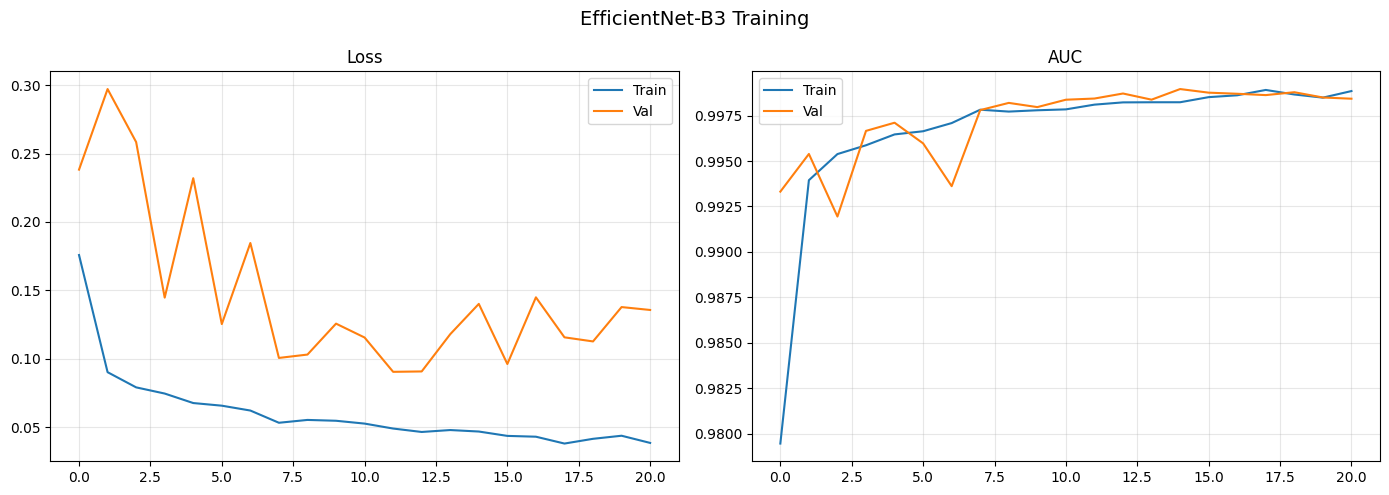


── Image Screener Results ──
AUC       : 0.9982
Accuracy  : 0.9403
F1        : 0.9408
Recall    : 0.8882
              precision    recall  f1-score   support

     Healthy       0.89      1.00      0.94      1093
        PCOS       1.00      0.89      0.94      1252

    accuracy                           0.94      2345
   macro avg       0.94      0.94      0.94      2345
weighted avg       0.95      0.94      0.94      2345



In [16]:


print("=== MODULE 2: Image Screener ===\n")

#  Transforms
train_tf = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


#  Subset helper
class SubsetDS(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        path  = self.dataset.image_paths[self.indices[idx]]
        label = self.dataset.labels[self.indices[idx]]
        try:
            img = Image.open(path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224))
        return self.transform(img), label


#  Stratified split
all_idx    = list(range(len(raw_dataset)))
all_labels = raw_dataset.labels

tr_idx, te_idx = train_test_split(
    all_idx, test_size=0.15,
    stratify=all_labels, random_state=SEED
)
tr_idx, va_idx = train_test_split(
    tr_idx, test_size=0.15,
    stratify=[all_labels[i] for i in tr_idx],
    random_state=SEED
)

train_ds = SubsetDS(raw_dataset, tr_idx, train_tf)
val_ds   = SubsetDS(raw_dataset, va_idx, val_tf)
test_ds  = SubsetDS(raw_dataset, te_idx, val_tf)

train_ldr = DataLoader(train_ds, batch_size=32,
                        shuffle=True,  num_workers=2,
                        pin_memory=True)
val_ldr   = DataLoader(val_ds,   batch_size=32,
                        shuffle=False, num_workers=2,
                        pin_memory=True)
test_ldr  = DataLoader(test_ds,  batch_size=32,
                        shuffle=False, num_workers=2,
                        pin_memory=True)

print(f"Image Train: {len(train_ds)} | "
      f"Val: {len(val_ds)} | Test: {len(test_ds)}")


# Model
class PCOSNet(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        self.base = models.efficientnet_b3(
            weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
        )
        # Freeze early layers
        for name, param in self.base.named_parameters():
            if any(x in name for x in
                   ['features.6','features.7','classifier']):
                param.requires_grad = True
            else:
                param.requires_grad = False

        in_feat = self.base.classifier[1].in_features
        self.base.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_feat, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.base(x).squeeze(1)


cnn_model = PCOSNet().to(device)
trainable = sum(p.numel() for p in cnn_model.parameters()
                if p.requires_grad)
print(f"Trainable params: {trainable:,}")

# ── Loss / Optimizer / Scheduler ─────────────────────────────
tr_labels  = [raw_dataset.labels[i] for i in tr_idx]
n_pos      = sum(tr_labels)
n_neg      = len(tr_labels) - n_pos
pos_weight = torch.tensor([n_neg / n_pos]).float().to(device)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = AdamW(
    filter(lambda p: p.requires_grad, cnn_model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler  = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)


#  Train / Eval loop
def run_epoch(model, loader, criterion,
              optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_probs, all_labels = 0, [], []

    with torch.set_grad_enabled(train):
        for imgs, labels in tqdm(loader, leave=False):
            imgs   = imgs.to(device)
            labels = labels.float().to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            all_probs.extend(
                torch.sigmoid(logits).cpu().detach().numpy()
            )
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc


#  Training loop
EPOCHS     = 25
best_auc   = 0
patience   = 6
no_improve = 0
history    = {'tr_loss':[], 'va_loss':[],
               'tr_auc':[],  'va_auc':[]}

print("\n── Training EfficientNet-B3 ──")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc = run_epoch(
        cnn_model, train_ldr, criterion, optimizer, True
    )
    va_loss, va_auc = run_epoch(
        cnn_model, val_ldr, criterion, train=False
    )
    scheduler.step()

    history['tr_loss'].append(tr_loss)
    history['va_loss'].append(va_loss)
    history['tr_auc'].append(tr_auc)
    history['va_auc'].append(va_auc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss:{tr_loss:.4f} AUC:{tr_auc:.4f} | "
          f"Val Loss:{va_loss:.4f} AUC:{va_auc:.4f}")

    if va_auc > best_auc:
        best_auc   = va_auc
        no_improve = 0
        torch.save(cnn_model.state_dict(), 'best_cnn.pth')
        print(f"  ✅ Saved (AUC:{best_auc:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"  ⏹  Early stop at epoch {epoch}")
            break

#  Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['tr_loss'], label='Train')
axes[0].plot(history['va_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(history['tr_auc'], label='Train')
axes[1].plot(history['va_auc'], label='Val')
axes[1].set_title('AUC'); axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle('EfficientNet-B3 Training', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Test evaluation
cnn_model.load_state_dict(torch.load('best_cnn.pth'))
_, auc_img = run_epoch(cnn_model, test_ldr, criterion, train=False)

# Collect test probabilities
cnn_model.eval()
img_probs, img_true = [], []
with torch.no_grad():
    for imgs, labels in test_ldr:
        logits = cnn_model(imgs.to(device))
        img_probs.extend(torch.sigmoid(logits).cpu().numpy())
        img_true.extend(labels.numpy())

y_prob_img  = np.array(img_probs)
y_true_img  = np.array(img_true)
y_pred_img  = (y_prob_img >= 0.5).astype(int)

print(f"\n── Image Screener Results ──")
print(f"AUC       : {roc_auc_score(y_true_img, y_prob_img):.4f}")
print(f"Accuracy  : {accuracy_score(y_true_img, y_pred_img):.4f}")
print(f"F1        : {f1_score(y_true_img, y_pred_img):.4f}")
print(f"Recall    : {recall_score(y_true_img, y_pred_img):.4f}")
print(classification_report(y_true_img, y_pred_img,
      target_names=['Healthy','PCOS']))

=== SHAP — Clinical XGBoost ===


/tmp/ipykernel_783/599826512.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_te_sc,


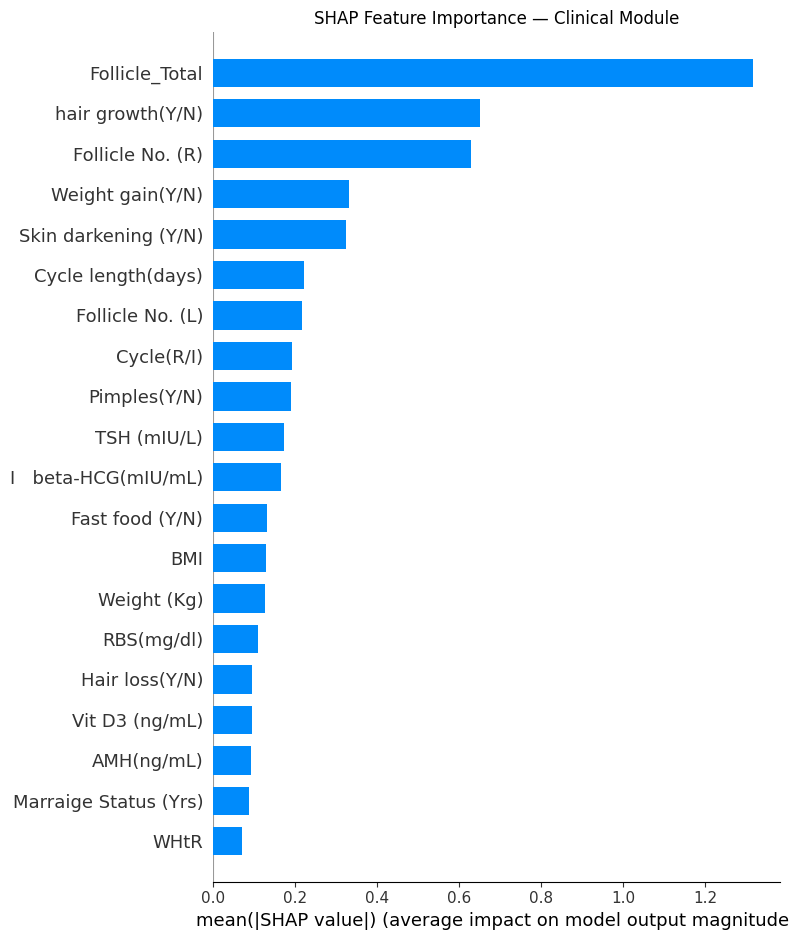

/tmp/ipykernel_783/599826512.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_te_sc,


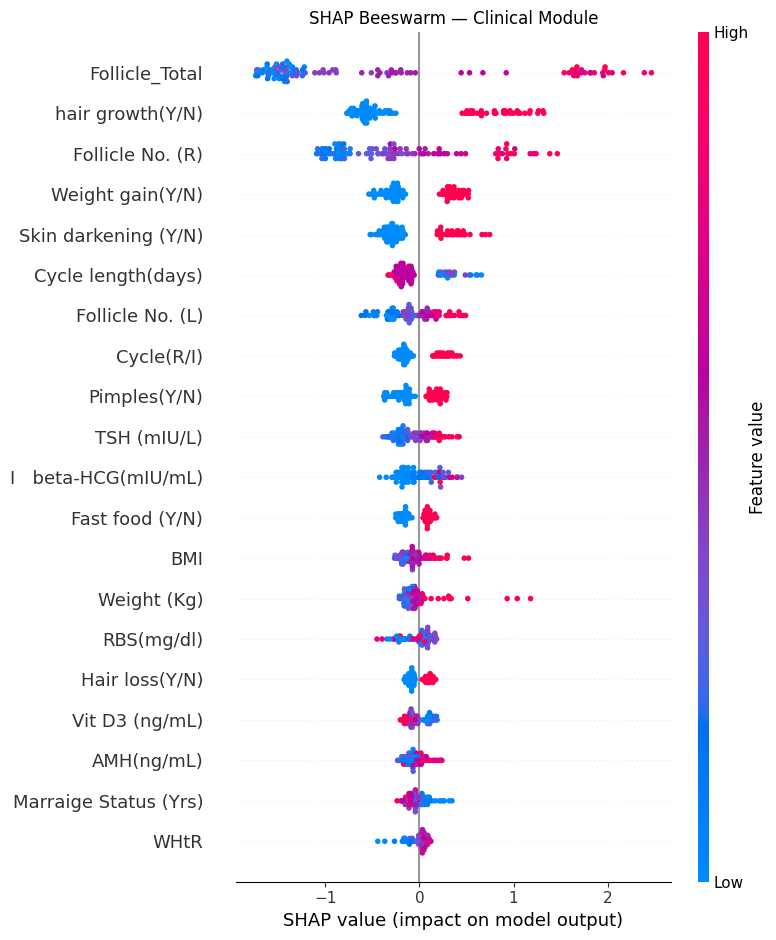


=== Grad-CAM — Image Module ===


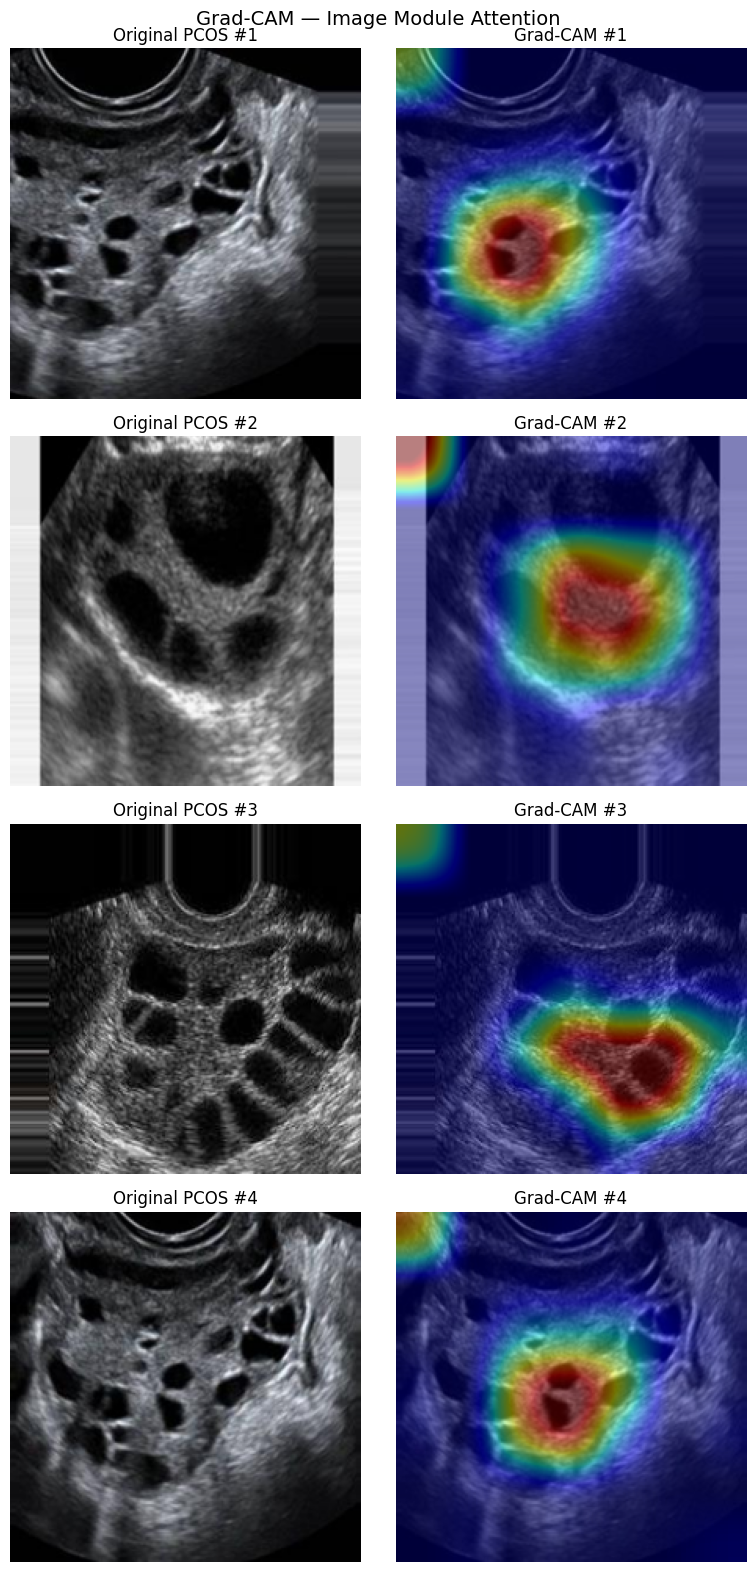

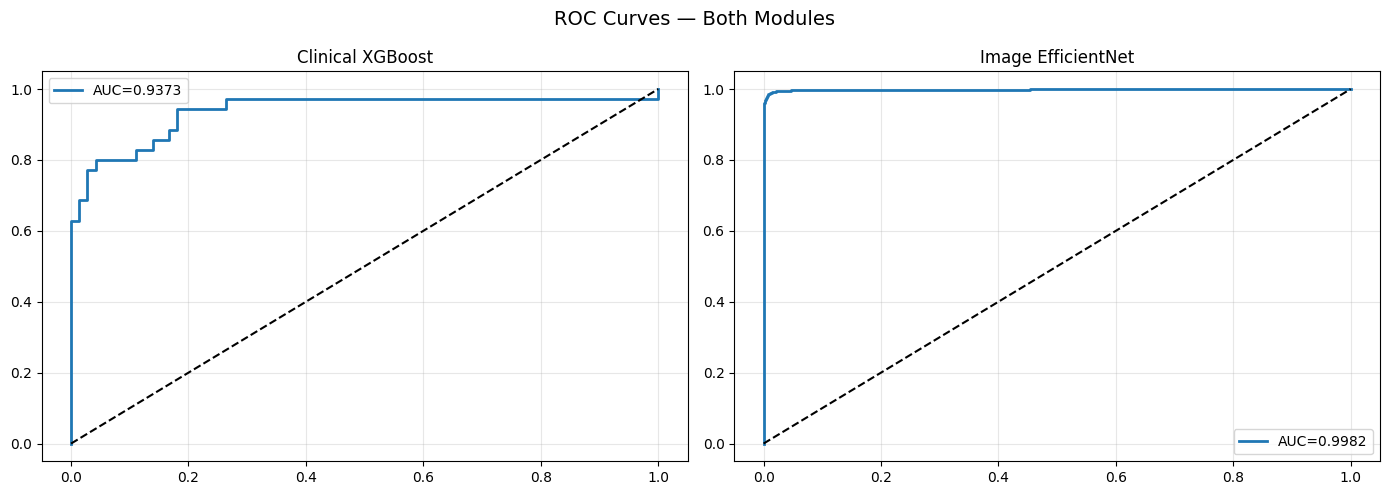

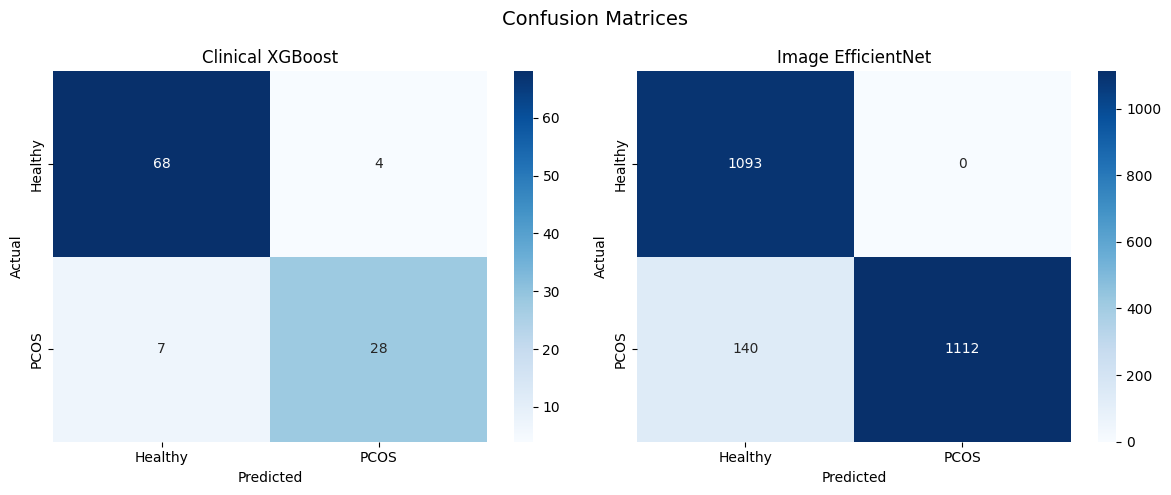

✅ All explainability plots saved


In [17]:


#  SHAP — Clinical Module
print("=== SHAP — Clinical XGBoost ===")
explainer   = shap.TreeExplainer(xgb_clinical)
shap_vals   = explainer.shap_values(X_te_sc)
feat_names  = X_tab.columns.tolist()

# Bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_te_sc,
                  feature_names=feat_names,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Clinical Module')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_te_sc,
                  feature_names=feat_names, show=False)
plt.title('SHAP Beeswarm — Clinical Module')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Grad-CAM — Image Module ───────────────────────────────────
print("\n=== Grad-CAM — Image Module ===")

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        self.activations = out.detach()

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, tensor):
        self.model.eval()
        tensor = tensor.unsqueeze(0).to(device)
        tensor.requires_grad_()
        out    = self.model(tensor)
        self.model.zero_grad()
        out.backward()

        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.relu(cam)
        cam     = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy()


gradcam    = GradCAM(cnn_model, cnn_model.base.features[-1])
pcos_idxs  = [i for i, l in enumerate(raw_dataset.labels)
               if l == 1][:4]

fig, axes = plt.subplots(4, 2, figsize=(8, 16))
for row, idx in enumerate(pcos_idxs):
    path    = raw_dataset.image_paths[idx]
    raw_img = Image.open(path).convert('RGB').resize((224,224))
    tensor  = val_tf(raw_img)
    cam     = gradcam.generate(tensor)
    cam_up  = np.array(
        Image.fromarray(
            (cam * 255).astype(np.uint8)
        ).resize((224, 224))
    )
    axes[row,0].imshow(raw_img)
    axes[row,0].set_title(f'Original PCOS #{row+1}')
    axes[row,0].axis('off')
    axes[row,1].imshow(raw_img)
    axes[row,1].imshow(cam_up, cmap='jet', alpha=0.45)
    axes[row,1].set_title(f'Grad-CAM #{row+1}')
    axes[row,1].axis('off')

plt.suptitle('Grad-CAM — Image Module Attention', fontsize=14)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()


# ── ROC + Confusion Matrix for both modules ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, yt, yp) in zip(axes, [
    ('Clinical XGBoost', y_te,      y_prob_cli),
    ('Image EfficientNet', y_true_img, y_prob_img),
]):
    fpr, tpr, _ = roc_curve(yt, yp)
    auc_v = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, lw=2, label=f'AUC={auc_v:.4f}')
    ax.plot([0,1],[0,1],'k--')
    ax.set_title(name); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — Both Modules', fontsize=14)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, yt, yp) in zip(axes, [
    ('Clinical XGBoost', y_te,       y_pred_cli),
    ('Image EfficientNet', y_true_img, y_pred_img),
]):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Healthy','PCOS'],
                yticklabels=['Healthy','PCOS'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ All explainability plots saved")

In [18]:

import nest_asyncio
nest_asyncio.apply()

os.makedirs('/content/pcos_app/models', exist_ok=True)

#  Copy models
for f in ['xgb_clinical.pkl','tab_scaler.pkl',
          'feature_cols.pkl','best_cnn.pth']:
    if os.path.exists(f'/content/{f}'):
        shutil.copy(f'/content/{f}',
                    f'/content/pcos_app/models/{f}')

#  requirements.txt
with open('/content/pcos_app/requirements.txt','w') as f:
    f.write("""\
fastapi==0.110.0
uvicorn==0.29.0
python-multipart==0.0.9
torch==2.2.2
torchvision==0.17.2
xgboost==2.0.3
scikit-learn==1.4.2
pandas==2.2.2
numpy==1.26.4
Pillow==10.3.0
openpyxl==3.1.2
""")

#  main.py
with open('/content/pcos_app/main.py','w') as f:
    f.write('''
import os, io, json, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from fastapi import FastAPI, File, UploadFile, Form, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
import uvicorn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load clinical pipeline
with open("models/xgb_clinical.pkl","rb") as f:
    xgb_clinical = pickle.load(f)
with open("models/tab_scaler.pkl","rb") as f:
    tab_scaler = pickle.load(f)
with open("models/feature_cols.pkl","rb") as f:
    feature_cols = pickle.load(f)

# Load CNN
class PCOSNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.efficientnet_b3(weights=None)
        in_feat = self.base.classifier[1].in_features
        self.base.classifier = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(in_feat,256),
            nn.ReLU(), nn.Dropout(0.2), nn.Linear(256,1)
        )
    def forward(self,x):
        return self.base(x).squeeze(1)

cnn = PCOSNet().to(device)
cnn.load_state_dict(
    torch.load("models/best_cnn.pth", map_location=device)
)
cnn.eval()

tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

THRESHOLD = 0.5
def risk(p):
    return "HIGH" if p>=0.75 else "MODERATE" if p>=THRESHOLD else "LOW"

def clinical_pred(d):
    row = pd.DataFrame([d])
    for c in feature_cols:
        if c not in row: row[c] = 0.0
    row = row[feature_cols]
    row["BMI"]            = row["Weight (Kg)"] / ((row["Height(Cm)"]/100)**2)
    row["LH_FSH_Ratio"]   = row["LH(mIU/mL)"] / (row["FSH(mIU/mL)"]+1e-5)
    row["Follicle_Total"] = row["Follicle No. (L)"] + row["Follicle No. (R)"]
    row["WHtR"]           = row["Waist(inch)"] / (row["Height(Cm)"]*0.393701)
    p = float(xgb_clinical.predict_proba(
        tab_scaler.transform(row))[0][1])
    return p

def image_pred(b):
    img = Image.open(io.BytesIO(b)).convert("RGB")
    t   = tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = float(torch.sigmoid(cnn(t)).item())
    return p

app = FastAPI(title="PCOS Detection API — Dual Module")
app.add_middleware(CORSMiddleware, allow_origins=["*"],
                   allow_methods=["*"], allow_headers=["*"])

@app.get("/")
def root():
    return {"status":"running",
            "modules":["clinical","imaging","both"]}

@app.get("/health")
def health():
    return {"status":"healthy","device":str(device)}

@app.post("/predict/clinical")
async def clinical_only(data: dict):
    try:
        p = clinical_pred(data)
        return {"module":"Clinical Screener",
                "pcos_probability":round(p,4),
                "prediction":"PCOS Detected" if p>=THRESHOLD else "Healthy",
                "risk_level":risk(p),
                "note":"Blood test analysis only"}
    except Exception as e:
        raise HTTPException(400, str(e))

@app.post("/predict/imaging")
async def imaging_only(file: UploadFile = File(...)):
    try:
        p = image_pred(await file.read())
        return {"module":"Image Screener",
                "pcos_probability":round(p,4),
                "prediction":"PCOS Detected" if p>=THRESHOLD else "Healthy",
                "risk_level":risk(p),
                "note":"Ultrasound image analysis only"}
    except Exception as e:
        raise HTTPException(400, str(e))

@app.post("/predict/both")
async def both(file: UploadFile = File(...),
               patient_data: str = Form(...)):
    try:
        p_cli = clinical_pred(json.loads(patient_data))
        p_img = image_pred(await file.read())
        agree = (
            (p_cli>=THRESHOLD) == (p_img>=THRESHOLD)
        )
        return {
            "clinical_module":{
                "pcos_probability":round(p_cli,4),
                "prediction":"PCOS Detected" if p_cli>=THRESHOLD else "Healthy",
                "risk_level":risk(p_cli)},
            "imaging_module":{
                "pcos_probability":round(p_img,4),
                "prediction":"PCOS Detected" if p_img>=THRESHOLD else "Healthy",
                "risk_level":risk(p_img)},
            "modules_agree": agree,
            "note":"✅ Both agree" if agree else
                   "⚠️ Modules disagree — clinician judgment needed",
            "disclaimer":"Final diagnosis must be made by a clinician"
        }
    except Exception as e:
        raise HTTPException(400, str(e))

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=8000)
''')

#  Dockerfile
with open('/content/pcos_app/Dockerfile','w') as f:
    f.write("""\
FROM python:3.10-slim
WORKDIR /app
RUN apt-get update && apt-get install -y \\
    libglib2.0-0 libsm6 libxext6 libxrender-dev \\
    && rm -rf /var/lib/apt/lists/*
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
EXPOSE 8000
CMD ["uvicorn","main:app","--host","0.0.0.0","--port","8000"]
""")

# ── docker-compose.yml
with open('/content/pcos_app/docker-compose.yml','w') as f:
    f.write("""\
version: "3.9"
services:
  pcos-api:
    build: .
    container_name: pcos_detection
    ports:
      - "8000:8000"
    volumes:
      - ./models:/app/models
    restart: unless-stopped
""")

#  PDF Report
!pip install reportlab -q
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import (SimpleDocTemplate, Paragraph,
    Spacer, Table, TableStyle, Image as RLImage)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch

doc    = SimpleDocTemplate('/content/pcos_app/PCOS_Report.pdf',
                            pagesize=A4)
styles = getSampleStyleSheet()
story  = []

title_style = ParagraphStyle('t', fontSize=20, spaceAfter=10,
    textColor=colors.HexColor('#7B2D8B'), fontName='Helvetica-Bold')
story.append(Paragraph("PCOS Detection System — Project Report", title_style))
story.append(Paragraph("Dual-Module AI: Clinical + Ultrasound (Independent)", styles['Normal']))
story.append(Spacer(1, 0.3*inch))

story.append(Paragraph("Architecture", styles['Heading2']))
arch = [
    ['Module',   'Model',           'Dataset',       'Task'],
    ['Clinical', 'XGBoost (500 trees)', 'PCOS xlsx (541 patients)', 'Blood test screening'],
    ['Imaging',  'EfficientNet-B3', 'Ultrasound images (~3000)', 'Scan screening'],
]
at = Table(arch, colWidths=[1.2*inch,1.8*inch,2.2*inch,1.8*inch])
at.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),colors.HexColor('#7B2D8B')),
    ('TEXTCOLOR',(0,0),(-1,0),colors.white),
    ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
    ('ROWBACKGROUNDS',(0,1),(-1,-1),
     [colors.white, colors.HexColor('#F3E8F7')]),
    ('GRID',(0,0),(-1,-1),0.5,colors.grey),
    ('FONTSIZE',(0,0),(-1,-1),9),
    ('PADDING',(0,0),(-1,-1),6),
]))
story.append(at)
story.append(Spacer(1, 0.3*inch))

story.append(Paragraph("Results", styles['Heading2']))
results = [
    ['Module',     'AUC',  'Accuracy','F1','Recall'],
    ['Clinical XGBoost',
     f'{roc_auc_score(y_te, y_prob_cli):.4f}',
     f'{accuracy_score(y_te, y_pred_cli):.4f}',
     f'{f1_score(y_te, y_pred_cli):.4f}',
     f'{recall_score(y_te, y_pred_cli):.4f}'],
    ['Image EfficientNet',
     f'{roc_auc_score(y_true_img, y_prob_img):.4f}',
     f'{accuracy_score(y_true_img, y_pred_img):.4f}',
     f'{f1_score(y_true_img, y_pred_img):.4f}',
     f'{recall_score(y_true_img, y_pred_img):.4f}'],
]
rt = Table(results,colWidths=[2.0*inch,1.0*inch,1.1*inch,1.0*inch,1.0*inch])
rt.setStyle(TableStyle([
    ('BACKGROUND',(0,0),(-1,0),colors.HexColor('#7B2D8B')),
    ('TEXTCOLOR',(0,0),(-1,0),colors.white),
    ('FONTNAME',(0,0),(-1,0),'Helvetica-Bold'),
    ('ROWBACKGROUNDS',(0,1),(-1,-1),
     [colors.white,colors.HexColor('#F3E8F7')]),
    ('GRID',(0,0),(-1,-1),0.5,colors.grey),
    ('FONTSIZE',(0,0),(-1,-1),9),
    ('PADDING',(0,0),(-1,-1),6),
]))
story.append(rt)
story.append(Spacer(1,0.3*inch))

for img_file, caption in [
    ('roc_curves.png',         'ROC Curves'),
    ('confusion_matrices.png', 'Confusion Matrices'),
    ('shap_beeswarm.png',      'SHAP Feature Importance'),
    ('gradcam.png',            'Grad-CAM Heatmaps'),
    ('training_curves.png',    'CNN Training Curves'),
]:
    path = f'/content/{img_file}'
    if os.path.exists(path):
        story.append(Paragraph(caption, styles['Heading3']))
        story.append(RLImage(path, width=6*inch, height=3*inch))
        story.append(Spacer(1, 0.2*inch))

doc.build(story)

# ── Zip everything ────────────────────────────────────────────
shutil.make_archive('/content/PCOS_Detection_App','zip',
                    '/content/pcos_app')

print("""
╔══════════════════════════════════════════════════╗
║       PCOS DETECTION SYSTEM — COMPLETE ✅        ║
╠══════════════════════════════════════════════════╣
║  Module 1 → Clinical XGBoost (blood tests)      ║
║  Module 2 → EfficientNet-B3 (ultrasound)        ║
║  SHAP     → Clinical explainability             ║
║  Grad-CAM → Image explainability                ║
║  FastAPI  → 3 endpoints (clinical/image/both)   ║
║  Docker   → One command deployment              ║
║  PDF      → Full results report                 ║
╠══════════════════════════════════════════════════╣
║  Files:                                          ║
║  📦 PCOS_Detection_App.zip                      ║
║  📄 PCOS_Report.pdf                             ║
╠══════════════════════════════════════════════════╣
║  Deploy:                                         ║
║  $ unzip PCOS_Detection_App.zip                 ║
║  $ docker-compose up --build                    ║
║  → http://localhost:8000/docs                   ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║       PCOS DETECTION SYSTEM — COMPLETE ✅        ║
╠══════════════════════════════════════════════════╣
║  Module 1 → Clinical XGBoost (blood tests)      ║
║  Module 2 → EfficientNet-B3 (ultrasound)        ║
║  SHAP     → Clinical explainability             ║
║  Grad-CAM → Image explainability                ║
║  FastAPI  → 3 endpoints (clinical/image/both)   ║
║  Docker   → One command deployment              ║
║  PDF      → Full results report                 ║
╠══════════════════════════════════════════════════╣
║  Files:                                          ║
║  📦 PCOS_Detection_App.zip                      ║
║  📄 PCOS_Report.pdf                             ║
╠══════════════════════════════════════════════════╣
║  Deploy:                                         ║
║  $ unzip PCOS_Detection_App.zip                 ║
║  $ docker-compose up --build                    ║
║  → http://localhost:8000/docs                   ║
╚══════